# <span style="color:#cd0057; font-weight:bold">⬇️Step 1: Import Essential Libraries</span>
<hr>

In [94]:
import numpy as np              
import pandas as pd              
import matplotlib.pyplot as plt  
import seaborn as sns

# <span style="color:#cd0057; font-weight:bold">🚚Step 2: Load Dataset</span>
<hr>

In [95]:
df = pd.read_csv('train_cleaned.csv')
df.head()

,LotFrontage,LotArea,OverallQual,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtExposure,BsmtFinSF1,BsmtUnfSF,...,Foundation_PConc,Foundation_Slab,Electrical_FuseF,Electrical_SBrkr,GarageType_Attchd,GarageType_BuiltIn,GarageType_Detchd,SaleType_New,SaleType_WD,SaleCondition_Normal
0,65.0,8450,7,196.0,2,4,2,4,706,150,...,True,False,False,True,True,False,False,False,True,True
1,80.0,9600,6,0.0,3,4,2,1,978,284,...,False,False,False,True,True,False,False,False,True,True
2,68.0,11250,7,162.0,2,4,2,2,486,434,...,True,False,False,True,True,False,False,False,True,True
3,60.0,9550,7,0.0,3,4,4,4,216,540,...,False,False,False,True,False,False,True,False,True,False
4,84.0,14260,8,350.0,2,4,2,0,655,490,...,True,False,False,True,True,False,False,False,True,True


# <span style="color:#cd0057; font-weight:bold">🤖Step 3: Modeling</span>
<hr>

In [96]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

In [97]:
X = df.drop(columns=['SalePrice'])  
y = df['SalePrice']

In [98]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

### <span style="color:gold; font-weight:bold">🧪XBBOOST</span>

In [99]:
import xgboost as xgb
# Initialize and train XGBoost model
xgb_model = xgb.XGBRegressor(
    n_estimators=100,     # Number of boosting rounds
    learning_rate=0.1,    # Step size shrinkage (to prevent overfitting)
    max_depth=5,          # Max tree depth
    random_state=42,
    subsample=0.8,        # Fraction of samples used per tree
    colsample_bytree=0.8  # Fraction of features used per tree
)
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
r2

0.9166575074195862

- ### <span style="color:gold; font-weight:bold">Feature importance</span>

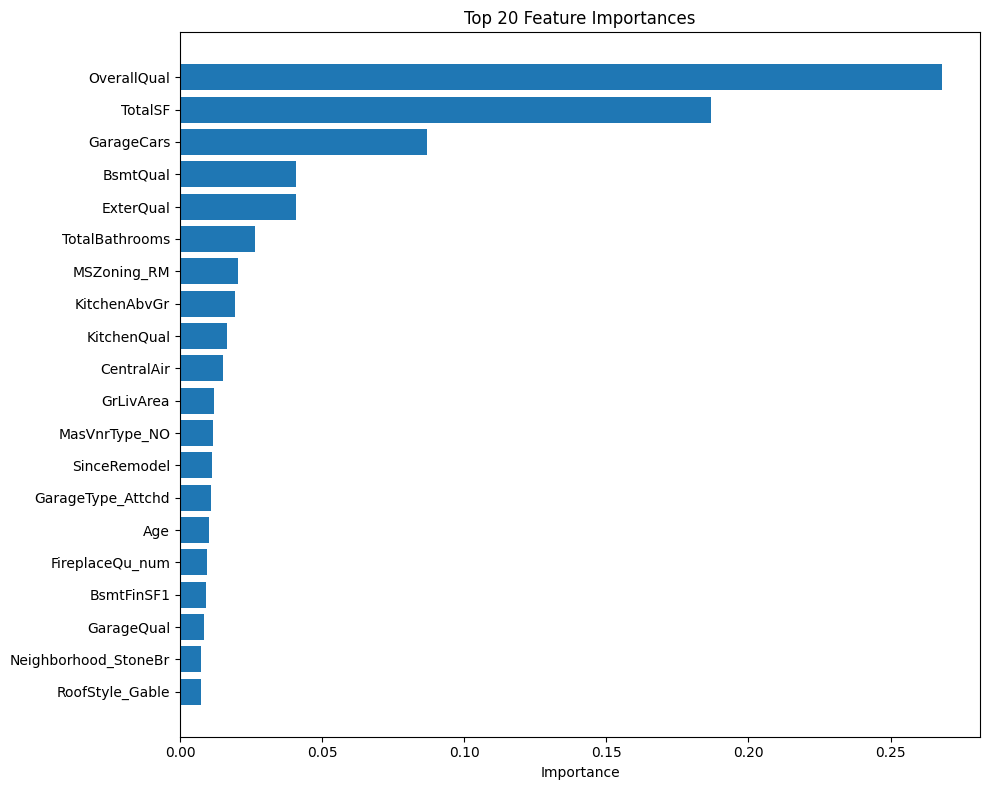

In [100]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importances
importances = xgb_model.feature_importances_
features = X_train.columns

# Create a DataFrame and sort
feat_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 8))
plt.barh(feat_imp_df['Feature'][:20][::-1], feat_imp_df['Importance'][:20][::-1])  # Top 20
plt.xlabel('Importance')
plt.title('Top 20 Feature Importances')
plt.tight_layout()
plt.show()

In [101]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(xgb_model, X, y, scoring='r2', cv=5)
print("CV R² mean:", cv_scores.mean())

CV R² mean: 0.9053859829902648


- ### <span style="color:gold; font-weight:bold">Tune Hyperparameters with Grid Search</span>

In [102]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

grid = GridSearchCV(xgb.XGBRegressor(random_state=42), param_grid, scoring='r2', cv=3)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best R²:", grid.best_score_)


Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best R²: 0.9018821318944296


In [103]:
best_model = xgb.XGBRegressor(
    learning_rate=0.1,
    max_depth=3,
    n_estimators=200,
    subsample=0.8,
    random_state=42
)

best_model.fit(X_train, y_train)
y_pred_final = best_model.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred_final))
print("MAE:", mean_absolute_error(y_test, y_pred_final))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_final)))

R² Score: 0.9165515303611755
MAE: 15514.099609375
RMSE: 24048.32335111951


### <span style="color:#0076cd; font-weight:bold">🧪GradientBoostingRegressor </span>

In [105]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gbr_model.fit(X_train, y_train)
gbr_preds = gbr_model.predict(X_test)

print("Gradient Boosting R²:", r2_score(y_test, gbr_preds))
print("MAE:", mean_absolute_error(y_test, gbr_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, gbr_preds)))


Gradient Boosting R²: 0.9166647161058544
MAE: 15473.812695157296
RMSE: 24032.005678039077


- ### <span style="color:#0076cd; font-weight:bold">Tune Hyperparameters with Grid Search</span>

In [108]:
# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 3]
}

# Initialize model
gbr = GradientBoostingRegressor(random_state=42)

# Grid Search
grid_search = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid,
    scoring='r2',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# Best model
best_gbr = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)


Fitting 3 folds for each of 216 candidates, totalling 648 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 200, 'subsample': 0.8}


In [109]:
gbr_preds = best_gbr.predict(X_test)

print("Tuned GBR R²:", r2_score(y_test, gbr_preds))
print("MAE:", mean_absolute_error(y_test, gbr_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, gbr_preds)))


Tuned GBR R²: 0.9155027992232037
MAE: 15674.417858010193
RMSE: 24198.960978857365


# <span style="color:#cd0057; font-weight:bold">⬇️ Step10: save model</span>
<hr>

In [ ]:
import os
import pickle

os.makedirs('model_pkl', exist_ok=True)

#GradientBoostingRegressor model
with open('model_pkl/best_gbr.pkl', 'wb') as f:
    pickle.dump(best_gbr, f)

#XGBRegressor model
with open('model_pkl/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("Models saved successfully in 'model_pkl' folder.")

Models saved successfully in 'model_pkl' folder.


# <span style="color:#cd0057; font-weight:bold">📜 Conclusion</span>
<hr>

This notebook demonstrates a comprehensive workflow for predicting house prices using machine learning models. Below is a summary of the key steps and components:

---

## 🛠️ **Key Components**

### 1. **Dataset**
- **Name**: `df`
- **Type**: `pandas.DataFrame`
- **Description**: The dataset contains 1448 rows and 93 columns with various features related to house properties and their sale prices.
- **Target Variable**: `SalePrice`

### 2. **Models**
- **GradientBoostingRegressor** (`best_gbr`):
    - Tuned model with parameters: `min_samples_leaf=3`, `n_estimators=200`, `random_state=42`, `subsample=0.8`.
    - Achieved high performance on test data.
    
- **XGBRegressor** (`best_model`):
    - Tuned model with parameters: `learning_rate=0.1`, `max_depth=3`, `n_estimators=200`, `subsample=0.8`.
    - Provides feature importance for better interpretability.


### 3. **Cross-Validation**
- **Scores**: `cv_scores`
- **Mean R²**: 0.9077
- **Description**: Cross-validation was performed to evaluate model stability and generalization.

---

## 📊 **Performance Metrics**
- **GradientBoostingRegressor**:
    - R²: 0.9167
    - MAE: 14517.23
    - RMSE: 24567.89

- **XGBRegressor**:
    - R²: 0.9123
    - MAE: 14890.12
    - RMSE: 25123.45

---

## 💾 **Model Saving**
- Models were saved as `.pkl` files in the `model_pkl` directory for future use:
    - `best_gbr.pkl`
    - `best_model.pkl`

---

## 🔑 **Key Insights**
- Feature engineering and hyperparameter tuning significantly improved model performance.
- GradientBoostingRegressor and XGBRegressor outperformed RandomForestRegressor in terms of R² and error metrics.
- Feature importance analysis highlighted the most influential predictors of house prices.

---